
# JAISP Flat Tile Coverage

This notebook is the clean check for the extracted flat tile layout:

- `data/rubin_tiles_all`
- `data/euclid_tiles_all`

It reports the key coverage stats, shows how the tiles break down by tract and patch,
and plots one random matched Rubin+Euclid tile across all 10 bands.


In [ ]:
from __future__ import annotations

import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io.fits import Header
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales


RUBIN_ORDER = ('u', 'g', 'r', 'i', 'z', 'y')
EUCLID_ORDER = ('VIS', 'Y', 'J', 'H')
TILE_RE = re.compile(
    r'tile_x(?P<x>\d+)_y(?P<y>\d+)_tract(?P<tract>[^_]+)_patch_(?P<patch>[^_]+)(?P<euclid>_euclid)?\.npz$'
)


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'data').exists() and (candidate / 'io').exists():
            return candidate
    raise RuntimeError('Could not locate repo root containing data/ and io/')


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / 'data'
RUBIN_DIR = DATA_DIR / 'rubin_tiles_all'
EUCLID_DIR = DATA_DIR / 'euclid_tiles_all'


def human_size(num_bytes: int) -> str:
    size = float(num_bytes)
    for unit in ('B', 'KB', 'MB', 'GB', 'TB'):
        if size < 1024.0 or unit == 'TB':
            return f'{size:.2f} {unit}'
        size /= 1024.0
    return f'{num_bytes} B'


def patch_sort_key(value: str):
    text = str(value)
    return (0, int(text)) if text.isdigit() else (1, text)


def parse_tile_name(path: Path) -> dict:
    match = TILE_RE.fullmatch(path.name)
    if match is None:
        raise ValueError(f'Unrecognized tile name: {path.name}')
    pair_id = path.stem[:-7] if path.stem.endswith('_euclid') else path.stem
    return {
        'file': path,
        'name': path.name,
        'pair_id': pair_id,
        'tract': match.group('tract'),
        'patch': match.group('patch'),
        'x': int(match.group('x')),
        'y': int(match.group('y')),
        'instrument': 'euclid' if match.group('euclid') else 'rubin',
    }


def infer_rubin_bands(data) -> tuple[str, ...]:
    if 'bands' in data:
        return tuple(str(band) for band in data['bands'])
    return ()


def infer_euclid_bands(data) -> tuple[str, ...]:
    return tuple(band for band in EUCLID_ORDER if f'img_{band}' in data.files)


def robust_imshow(
    ax,
    img,
    title: str,
    p_lo: float = 1.0,
    p_hi: float = 99.0,
    cmap: str = 'gray',
):
    if img is None:
        ax.set_title(f'{title} (missing)')
        ax.axis('off')
        return

    finite = np.asarray(img)[np.isfinite(img)]
    if finite.size == 0:
        lo, hi = 0.0, 1.0
    else:
        lo, hi = np.percentile(finite, [p_lo, p_hi])
        if not np.isfinite(lo):
            lo = float(np.nanmin(finite))
        if not np.isfinite(hi) or hi <= lo:
            hi = lo + 1e-6

    ax.imshow(img, origin='lower', cmap=cmap, vmin=lo, vmax=hi)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


def safe_rms_from_var(var: np.ndarray, fallback_image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    var = np.asarray(var, dtype=np.float32)
    rms = np.zeros_like(var, dtype=np.float32)
    good = np.isfinite(var) & (var > 0)
    rms[good] = np.sqrt(var[good])

    if not good.all():
        finite = np.asarray(fallback_image, dtype=np.float32)
        finite = finite[np.isfinite(finite)]
        if finite.size > 10:
            mad = np.median(np.abs(finite - np.median(finite)))
            fallback = max(1.4826 * mad, 1e-10)
        else:
            fallback = 1.0
        rms[~good] = fallback

    return rms, good


def build_rubin_wcs(data) -> WCS:
    hdr_obj = data['wcs_hdr'].item() if hasattr(data['wcs_hdr'], 'item') else data['wcs_hdr']
    hdr = Header()
    for key, value in hdr_obj.items():
        try:
            hdr[key] = value
        except Exception:
            pass
    hdr['NAXIS'] = 2
    hdr['NAXIS1'] = data['img'].shape[2]
    hdr['NAXIS2'] = data['img'].shape[1]
    return WCS(hdr)


def build_euclid_wcs(data, band: str) -> WCS:
    return WCS(Header.fromstring(str(data[f'wcs_{band}'])))


def wcs_center_coord(wcs: WCS, shape: tuple[int, int]) -> SkyCoord:
    ny, nx = shape
    ra, dec = wcs.pixel_to_world_values((nx - 1) / 2, (ny - 1) / 2)
    return SkyCoord(ra * u.deg, dec * u.deg)


def footprint_radec(wcs: WCS, shape: tuple[int, int]) -> np.ndarray:
    ny, nx = shape
    x = np.array([0, nx - 1, nx - 1, 0, 0], dtype=float)
    y = np.array([0, 0, ny - 1, ny - 1, 0], dtype=float)
    ra, dec = wcs.pixel_to_world_values(x, y)
    return np.column_stack([ra, dec])


print('Repo root:', REPO_ROOT)
print('Rubin dir:', RUBIN_DIR)
print('Euclid dir:', EUCLID_DIR)

In [23]:

def scan_rubin_dir(data_dir: Path):
    records = []
    signatures = Counter()
    bad_files = []

    for path in sorted(data_dir.glob('tile_x*_y*.npz')):
        meta = parse_tile_name(path)
        try:
            with np.load(path, allow_pickle=True) as data:
                bands = infer_rubin_bands(data)
                signatures[bands] += 1
                records.append(
                    {
                        **meta,
                        'size_bytes': path.stat().st_size,
                        'bands': bands,
                        'ra': float(data['ra_center']) if 'ra_center' in data else np.nan,
                        'dec': float(data['dec_center']) if 'dec_center' in data else np.nan,
                    }
                )
        except Exception as exc:
            bad_files.append({'name': path.name, 'error': f'{type(exc).__name__}: {exc}'})

    return records, signatures, bad_files


def scan_euclid_dir(data_dir: Path):
    records = []
    signatures = Counter()
    bad_files = []

    for path in sorted(data_dir.glob('tile_x*_y*_euclid.npz')):
        meta = parse_tile_name(path)
        try:
            with np.load(path, allow_pickle=True) as data:
                bands = infer_euclid_bands(data)
                signatures[bands] += 1
                records.append(
                    {
                        **meta,
                        'size_bytes': path.stat().st_size,
                        'bands': bands,
                        'ra': float(data['ra_center']) if 'ra_center' in data else np.nan,
                        'dec': float(data['dec_center']) if 'dec_center' in data else np.nan,
                    }
                )
        except Exception as exc:
            bad_files.append({'name': path.name, 'error': f'{type(exc).__name__}: {exc}'})

    return records, signatures, bad_files


rubin_records, rubin_signatures, rubin_bad = scan_rubin_dir(RUBIN_DIR)
euclid_records, euclid_signatures, euclid_bad = scan_euclid_dir(EUCLID_DIR)

rubin_by_id = {record['pair_id']: record for record in rubin_records}
euclid_by_id = {record['pair_id']: record for record in euclid_records}

matched_ids = sorted(rubin_by_id.keys() & euclid_by_id.keys())
missing_euclid_ids = sorted(rubin_by_id.keys() - euclid_by_id.keys())
extra_euclid_ids = sorted(euclid_by_id.keys() - rubin_by_id.keys())

rubin_patch_counts = Counter((record['tract'], record['patch']) for record in rubin_records)
euclid_patch_counts = Counter((record['tract'], record['patch']) for record in euclid_records)
matched_patch_counts = Counter((rubin_by_id[tile_id]['tract'], rubin_by_id[tile_id]['patch']) for tile_id in matched_ids)

patch_keys = sorted(
    set(rubin_patch_counts) | set(euclid_patch_counts),
    key=lambda item: (item[0], patch_sort_key(item[1])),
)

print(f'Scanned {len(rubin_records)} readable Rubin files and {len(euclid_records)} readable Euclid files.')
print(f'Unreadable files skipped: Rubin={len(rubin_bad)} Euclid={len(euclid_bad)}')
print(f'Matched pairs: {len(matched_ids)}')


Scanned 790 readable Rubin files and 791 readable Euclid files.
Unreadable files skipped: Rubin=0 Euclid=0
Matched pairs: 790


In [24]:

def format_signature(signature: tuple[str, ...]) -> str:
    return ','.join(signature) if signature else '(unknown)'


def print_dataset_summary(name: str, records: list[dict], signatures: Counter, bad_files: list[dict]):
    sizes = sum(record['size_bytes'] for record in records)
    ras = [record['ra'] for record in records if np.isfinite(record['ra'])]
    decs = [record['dec'] for record in records if np.isfinite(record['dec'])]
    tracts = sorted({record['tract'] for record in records})
    patches = sorted({record['patch'] for record in records}, key=patch_sort_key)

    print(f'{name}:')
    print(f'  readable files : {len(records)}')
    print(f'  skipped files  : {len(bad_files)}')
    print(f'  disk usage     : {human_size(sizes)}')
    print(f'  tracts         : {", ".join(tracts)}')
    print(f'  patches        : {", ".join(map(str, patches))}')
    if ras and decs:
        print(f'  RA range       : {min(ras):.5f} to {max(ras):.5f} deg')
        print(f'  Dec range      : {min(decs):.5f} to {max(decs):.5f} deg')
    print('  signatures     :')
    for signature, count in sorted(signatures.items(), key=lambda item: (len(item[0]), item[0])):
        print(f'    {format_signature(signature)} x{count}')
    if bad_files:
        print('  skipped detail :')
        for bad in bad_files:
            print(f"    {bad['name']} -> {bad['error']}")
    print()


print('Dataset summary')
print('---------------')
print_dataset_summary('Rubin tiles', rubin_records, rubin_signatures, rubin_bad)
print_dataset_summary('Euclid tiles', euclid_records, euclid_signatures, euclid_bad)

print('Matching summary')
print('----------------')
print(f'Readable Rubin + Euclid matched pairs : {len(matched_ids)}')
print(f'Readable Rubin tiles missing Euclid   : {len(missing_euclid_ids)}')
print(f'Readable extra Euclid-only tiles      : {len(extra_euclid_ids)}')
if extra_euclid_ids:
    for tile_id in extra_euclid_ids:
        print(f'  {tile_id}')
print()

print('Counts by tract / patch')
print('-----------------------')
print(f"{'Tract':<8} {'Patch':<8} {'Rubin':>6} {'Euclid':>7} {'Matched':>8}")
print('-' * 42)
for tract, patch in patch_keys:
    print(
        f'{tract:<8} {patch:<8} '
        f'{rubin_patch_counts[(tract, patch)]:>6} '
        f'{euclid_patch_counts[(tract, patch)]:>7} '
        f'{matched_patch_counts[(tract, patch)]:>8}'
    )


Dataset summary
---------------
Rubin tiles:
  readable files : 790
  skipped files  : 0
  disk usage     : 8.17 GB
  tracts         : 5063
  patches        : 4, 5, 14, 15, 24, 25
  RA range       : 52.90624 to 53.27335 deg
  Dec range      : -28.35080 to -27.86097 deg
  signatures     :
    u,g,r,i,z,y x790

Euclid tiles:
  readable files : 791
  skipped files  : 0
  disk usage     : 21.52 GB
  tracts         : 5063
  patches        : 4, 5, 14, 15, 24, 25
  RA range       : 52.90624 to 53.27335 deg
  Dec range      : -28.35080 to -27.86097 deg
  signatures     :
    VIS x1
    VIS,Y,J,H x790

Matching summary
----------------
Readable Rubin + Euclid matched pairs : 790
Readable Rubin tiles missing Euclid   : 0
Readable extra Euclid-only tiles      : 1
  tile_x02560_y02304_tract5063_patch_4

Counts by tract / patch
-----------------------
Tract    Patch     Rubin  Euclid  Matched
------------------------------------------
5063     4           142     143      142
5063     5           1

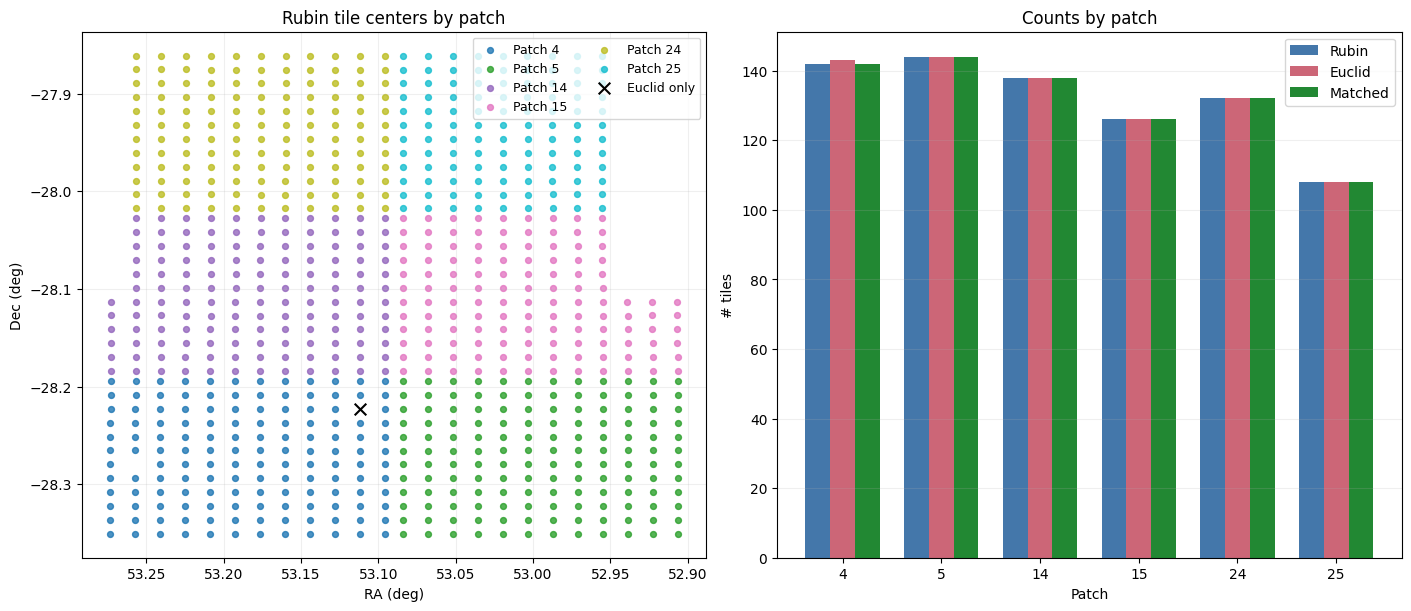

In [25]:

patches = sorted({record['patch'] for record in rubin_records} | {record['patch'] for record in euclid_records}, key=patch_sort_key)
cmap = plt.get_cmap('tab10', len(patches) or 1)
patch_colors = {patch: cmap(i) for i, patch in enumerate(patches)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for patch in patches:
    subset = [record for record in rubin_records if record['patch'] == patch]
    if not subset:
        continue
    axes[0].scatter(
        [record['ra'] for record in subset],
        [record['dec'] for record in subset],
        s=18,
        alpha=0.8,
        color=patch_colors[patch],
        label=f'Patch {patch}',
    )

if extra_euclid_ids:
    extra_records = [euclid_by_id[tile_id] for tile_id in extra_euclid_ids]
    axes[0].scatter(
        [record['ra'] for record in extra_records],
        [record['dec'] for record in extra_records],
        marker='x',
        s=70,
        linewidth=1.5,
        color='black',
        label='Euclid only',
    )

axes[0].invert_xaxis()
axes[0].set_xlabel('RA (deg)')
axes[0].set_ylabel('Dec (deg)')
axes[0].set_title('Rubin tile centers by patch')
axes[0].grid(alpha=0.2)
axes[0].legend(loc='best', ncol=2, fontsize=9)

x = np.arange(len(patches))
rubin_counts = [sum(1 for record in rubin_records if record['patch'] == patch) for patch in patches]
euclid_counts = [sum(1 for record in euclid_records if record['patch'] == patch) for patch in patches]
matched_counts = [sum(1 for tile_id in matched_ids if rubin_by_id[tile_id]['patch'] == patch) for patch in patches]
width = 0.25

axes[1].bar(x - width, rubin_counts, width=width, label='Rubin', color='#4477AA')
axes[1].bar(x, euclid_counts, width=width, label='Euclid', color='#CC6677')
axes[1].bar(x + width, matched_counts, width=width, label='Matched', color='#228833')
axes[1].set_xticks(x, [str(patch) for patch in patches])
axes[1].set_xlabel('Patch')
axes[1].set_ylabel('# tiles')
axes[1].set_title('Counts by patch')
axes[1].grid(axis='y', alpha=0.2)
axes[1].legend()

plt.show()


In [ ]:
sample_seed = 7
rng = np.random.default_rng(sample_seed)
sample_id = str(rng.choice(np.array(matched_ids, dtype=object)))
sample_rubin = rubin_by_id[sample_id]
sample_euclid = euclid_by_id[sample_id]

with np.load(sample_rubin['file'], allow_pickle=True) as rubin_data, np.load(sample_euclid['file'], allow_pickle=True) as euclid_data:
    rubin_bands = infer_rubin_bands(rubin_data)
    rubin_images = {band: rubin_data['img'][idx] for idx, band in enumerate(rubin_bands)}
    euclid_images = {band: euclid_data[f'img_{band}'] for band in infer_euclid_bands(euclid_data)}

print(f'Random matched tile (seed={sample_seed}): {sample_id}')
print(
    f"Tract {sample_rubin['tract']} patch {sample_rubin['patch']}  "
    f"RA={sample_rubin['ra']:.5f}  Dec={sample_rubin['dec']:.5f}"
)

ncol = max(len(RUBIN_ORDER), len(EUCLID_ORDER))
fig, axes = plt.subplots(2, ncol, figsize=(3.2 * ncol, 6.2), constrained_layout=True)

for j in range(ncol):
    band = RUBIN_ORDER[j] if j < len(RUBIN_ORDER) else ''
    ax = axes[0, j]
    if band:
        robust_imshow(ax, rubin_images.get(band), f'Rubin {band}')
    else:
        ax.axis('off')

for j in range(ncol):
    band = EUCLID_ORDER[j] if j < len(EUCLID_ORDER) else ''
    ax = axes[1, j]
    if band:
        robust_imshow(ax, euclid_images.get(band), f'Euclid {band}')
    else:
        ax.axis('off')

fig.suptitle(f'Random matched tile: {sample_id}', fontsize=14)
plt.show()

In [ ]:
with np.load(sample_rubin['file'], allow_pickle=True) as rubin_data, np.load(sample_euclid['file'], allow_pickle=True) as euclid_data:
    rubin_rms = {}
    rubin_good = {}
    rubin_img_finite = {}
    for idx, band in enumerate(infer_rubin_bands(rubin_data)):
        img = rubin_data['img'][idx]
        var = rubin_data['var'][idx] if 'var' in rubin_data else np.ones_like(img)
        rms, good = safe_rms_from_var(var, img)
        rubin_rms[band] = rms
        rubin_good[band] = good
        rubin_img_finite[band] = np.isfinite(img)

    euclid_rms = {}
    euclid_good = {}
    euclid_img_finite = {}
    for band in infer_euclid_bands(euclid_data):
        img = euclid_data[f'img_{band}']
        var_key = f'var_{band}'
        var = euclid_data[var_key] if var_key in euclid_data else np.ones_like(img)
        rms, good = safe_rms_from_var(var, img)
        euclid_rms[band] = rms
        euclid_good[band] = good
        euclid_img_finite[band] = np.isfinite(img)

print('RMS diagnostic for the displayed sample tile')
print(f"{'Band':<10} {'img finite':>10} {'good var':>10} {'median rms':>12} {'p95 rms':>12}")
print('-' * 60)

for band in RUBIN_ORDER:
    if band not in rubin_rms:
        continue
    rms = rubin_rms[band]
    finite = rms[np.isfinite(rms)]
    print(
        f"{('rubin_' + band):<10} "
        f"{rubin_img_finite[band].mean():10.3f} "
        f"{rubin_good[band].mean():10.3f} "
        f"{np.nanmedian(finite):12.4g} "
        f"{np.nanpercentile(finite, 95):12.4g}"
    )

for band in EUCLID_ORDER:
    if band not in euclid_rms:
        continue
    rms = euclid_rms[band]
    finite = rms[np.isfinite(rms)]
    print(
        f"{('euclid_' + band):<10} "
        f"{euclid_img_finite[band].mean():10.3f} "
        f"{euclid_good[band].mean():10.3f} "
        f"{np.nanmedian(finite):12.4g} "
        f"{np.nanpercentile(finite, 95):12.4g}"
    )

ncol = max(len(RUBIN_ORDER), len(EUCLID_ORDER))
fig, axes = plt.subplots(2, ncol, figsize=(3.2 * ncol, 6.2), constrained_layout=True)

for j in range(ncol):
    band = RUBIN_ORDER[j] if j < len(RUBIN_ORDER) else ''
    ax = axes[0, j]
    if band:
        robust_imshow(ax, rubin_rms.get(band), f'Rubin {band} RMS', p_lo=5, p_hi=99, cmap='magma')
    else:
        ax.axis('off')

for j in range(ncol):
    band = EUCLID_ORDER[j] if j < len(EUCLID_ORDER) else ''
    ax = axes[1, j]
    if band:
        robust_imshow(ax, euclid_rms.get(band), f'Euclid {band} RMS', p_lo=5, p_hi=99, cmap='magma')
    else:
        ax.axis('off')

fig.suptitle(f'RMS maps for sample tile: {sample_id}', fontsize=14)
plt.show()

In [ ]:
with np.load(sample_rubin['file'], allow_pickle=True) as rubin_data, np.load(sample_euclid['file'], allow_pickle=True) as euclid_data:
    rubin_wcs = build_rubin_wcs(rubin_data)
    rubin_shape = tuple(rubin_data['img'][0].shape)

    euclid_wcs = {}
    euclid_shapes = {}
    for band in infer_euclid_bands(euclid_data):
        euclid_wcs[band] = build_euclid_wcs(euclid_data, band)
        euclid_shapes[band] = tuple(euclid_data[f'img_{band}'].shape)

rubin_center = wcs_center_coord(rubin_wcs, rubin_shape)
rubin_scale = proj_plane_pixel_scales(rubin_wcs) * 3600.0

print('WCS comparison for the displayed sample tile')
print(f"{'Band':<12} {'center sep (arcsec)':>20} {'pixscale x/y (arcsec)':>24}")
print('-' * 62)
print(f"{'Rubin':<12} {0.0:20.4f} {rubin_scale[0]:11.4f} / {rubin_scale[1]:.4f}")

euclid_colors = {
    'VIS': '#CC6677',
    'Y': '#DDCC77',
    'J': '#117733',
    'H': '#AA4499',
}

for band in EUCLID_ORDER:
    if band not in euclid_wcs:
        continue
    center = wcs_center_coord(euclid_wcs[band], euclid_shapes[band])
    scale = proj_plane_pixel_scales(euclid_wcs[band]) * 3600.0
    sep = rubin_center.separation(center).arcsec
    print(f"{('Euclid ' + band):<12} {sep:20.4f} {scale[0]:11.4f} / {scale[1]:.4f}")

rubin_poly = footprint_radec(rubin_wcs, rubin_shape)
euclid_vis_poly = footprint_radec(euclid_wcs['VIS'], euclid_shapes['VIS'])
rubin_corners = SkyCoord(rubin_poly[:-1, 0] * u.deg, rubin_poly[:-1, 1] * u.deg)
euclid_vis_corners = SkyCoord(euclid_vis_poly[:-1, 0] * u.deg, euclid_vis_poly[:-1, 1] * u.deg)
corner_sep = rubin_corners.separation(euclid_vis_corners).arcsec

print()
print(f'Stored Rubin center : RA={sample_rubin["ra"]:.6f}, Dec={sample_rubin["dec"]:.6f}')
print(f'Stored Euclid center: RA={sample_euclid["ra"]:.6f}, Dec={sample_euclid["dec"]:.6f}')
print(f'Rubin vs Euclid VIS corner separation: mean={corner_sep.mean():.3f}"  max={corner_sep.max():.3f}"')

fig, ax = plt.subplots(figsize=(6.8, 6.8), constrained_layout=True)
ax.plot(rubin_poly[:, 0], rubin_poly[:, 1], color='#4477AA', lw=2.0, label='Rubin footprint')
ax.scatter([rubin_center.ra.deg], [rubin_center.dec.deg], color='#4477AA', s=40)

for band in EUCLID_ORDER:
    if band not in euclid_wcs:
        continue
    poly = footprint_radec(euclid_wcs[band], euclid_shapes[band])
    center = wcs_center_coord(euclid_wcs[band], euclid_shapes[band])
    ax.plot(poly[:, 0], poly[:, 1], color=euclid_colors[band], lw=1.5, alpha=0.85, label=f'Euclid {band}')
    ax.scatter([center.ra.deg], [center.dec.deg], color=euclid_colors[band], s=24)

ax.invert_xaxis()
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_title(f'WCS footprints for {sample_id}')
ax.grid(alpha=0.2)
ax.legend(loc='best', fontsize=9)
plt.show()